## Load

In [ ]:
%pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("shwetabh123/mall-customers")
dataset_path = "/".join((path, "Mall_Customers.csv"))

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers' dataset.
Path to dataset files: /kaggle/input/mall-customers


In [ ]:
df = pd.read_csv(dataset_path)
# df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Exploration

### describe

In [ ]:
import numpy as np
print(df.info())
display(df.select_dtypes(include=[np.number]).describe())
display(df.select_dtypes(exclude=[np.number]).describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


,Genre
count,200
unique,2
top,Female
freq,112


### isna

In [ ]:
print("Nan values:")
display(df.isna().sum().sort_values(ascending=False))


Nan values:


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Distribution Histograms

Age: max=70, unique=51, bins=14, discrete=False


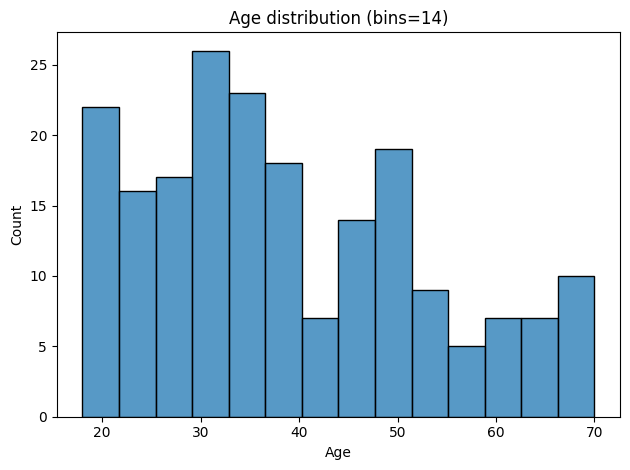

Annual Income (k$): max=137, unique=64, bins=14, discrete=False


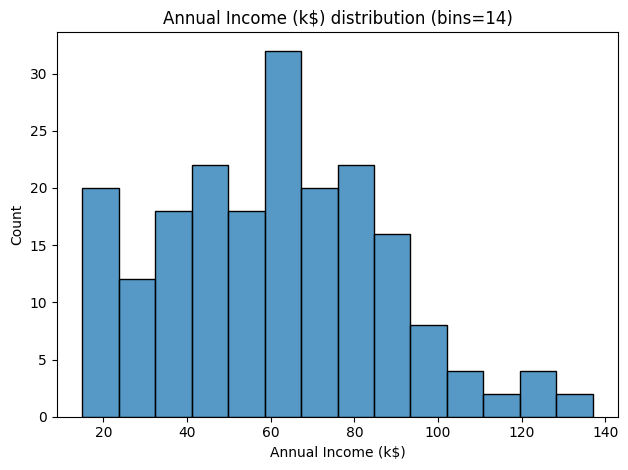

Spending Score (1-100): max=99, unique=84, bins=14, discrete=False


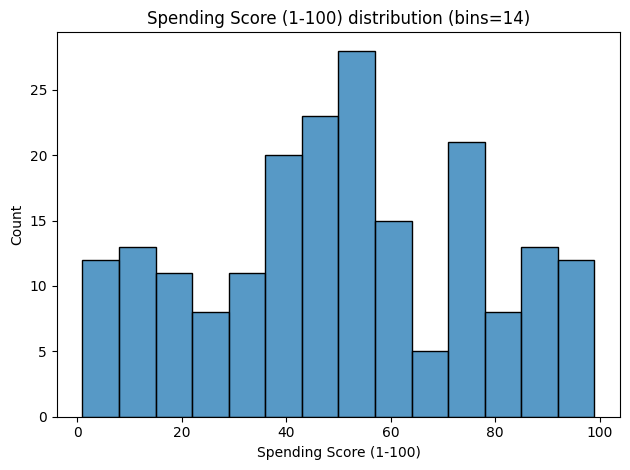

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
  if c == 'CustomerID':
    continue
  cleaned = df[c].dropna()
  max_val = cleaned.max()
  n = len(cleaned)
  # Decide bins:
  # If data look like small-range integers (few unique values) use that count (discrete histogram)
  n_unique = cleaned.nunique()
  use_discrete = False
  if pd.api.types.is_integer_dtype(cleaned) and 1 < n_unique <= 20:
      bins = n_unique
      use_discrete = True
  else:
      # Fallback: Freedman–Diaconis inspired simple heuristic (sqrt fallback) capped
      # sqrt(n) is a simple rule-of-thumb; keep within [10, 40]
      bins = int(np.sqrt(n)) if n > 0 else 1
      bins = max(10, min(40, bins))
  print(f'{c}: max={max_val}, unique={n_unique}, bins={bins}, discrete={use_discrete}')
  sns.histplot(cleaned, bins=bins, discrete=use_discrete)
  plt.title(f'{c} distribution (bins={bins})')
  plt.tight_layout()
  plt.show()

### Categorical features distribution

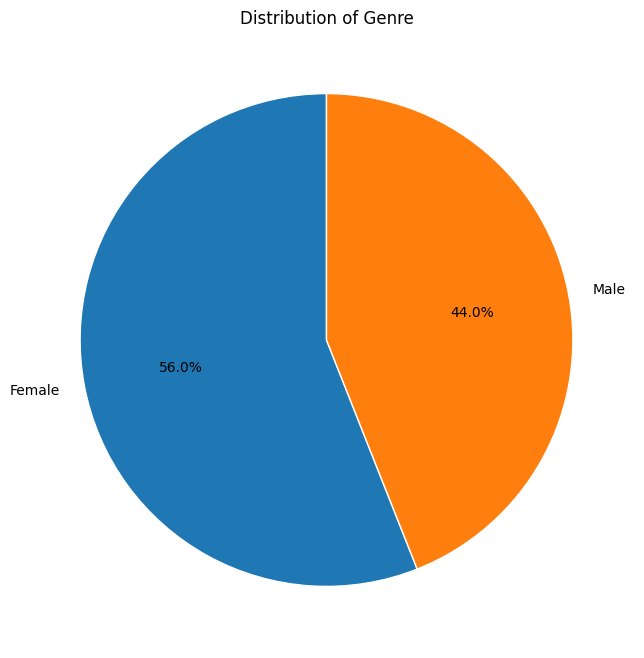

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 8))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
    plt.title(f'Distribution of {col}')
    plt.ylabel('') # Remove default y-label
    plt.show()

## Missing vals

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    nan_count = df[col].isna().sum()
    print(f"Column '{col}': 0 values = {zero_count}, NaN values = {nan_count}")

Column 'CustomerID': 0 values = 0, NaN values = 0
Column 'Age': 0 values = 0, NaN values = 0
Column 'Annual Income (k$)': 0 values = 0, NaN values = 0
Column 'Spending Score (1-100)': 0 values = 0, NaN values = 0


## Feature selection

In [ ]:
df = df.drop('CustomerID', axis=1)

display(df.head())

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Outliers

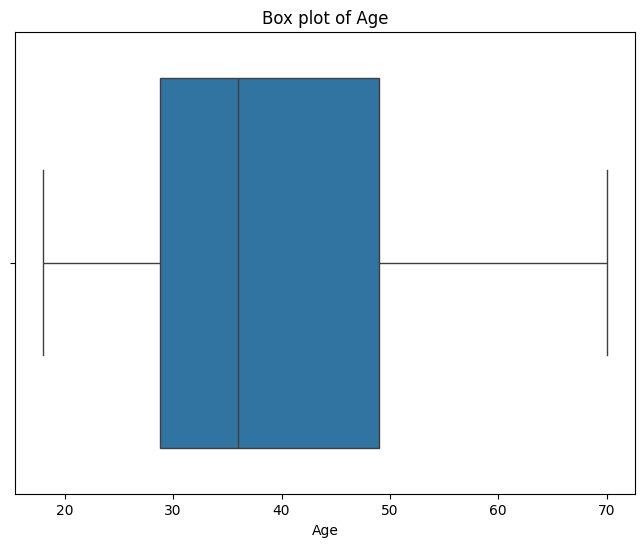

Number of outliers in 'Age': 0


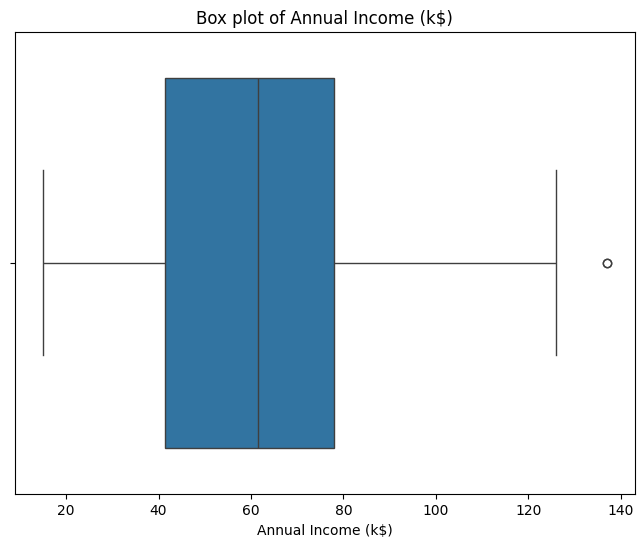

Number of outliers in 'Annual Income (k$)': 2


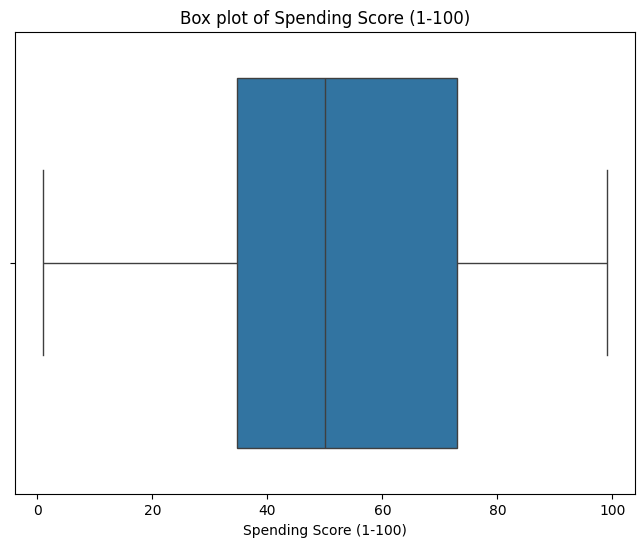

Number of outliers in 'Spending Score (1-100)': 0
Columns to handle outliers: ['Annual Income (k$)']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

handle_ol = []
# Create box plots and print the number of outliers for each numerical column
for col in num_cols:
  if col == 'CustomerID':
    continue
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[col])
  plt.title(f'Box plot of {col}')
  plt.xlabel(col)
  plt.show()

  # Calculate the number of outliers using IQR
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  if len(outliers) > 0:
    handle_ol.append(col)

  print(f"Number of outliers in '{col}': {len(outliers)}")

print(f"Columns to handle outliers: {handle_ol}")

1% small outliers in `Annual Income` => cap

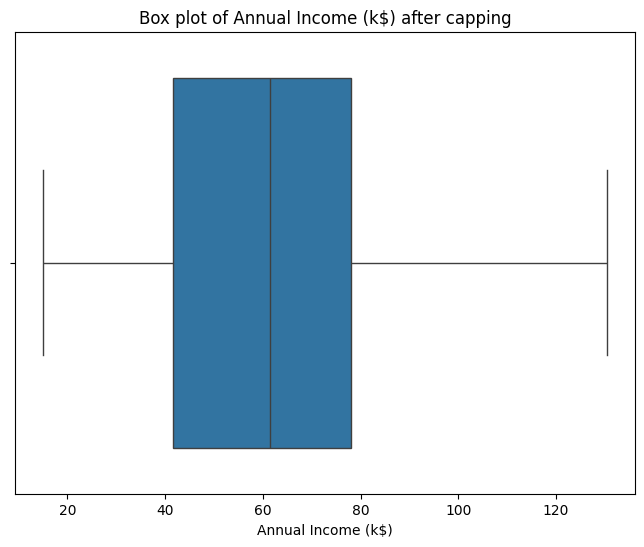

Number of outliers in 'Annual Income (k$)' after capping: 0


In [ ]:
# Cap the outliers in 'Annual Income (k$)' to the upper bound
df['Annual Income (k$)'] = np.where(df['Annual Income (k$)'] > upper_bound, upper_bound, df['Annual Income (k$)'])

# Verify the capping by checking for outliers again
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Annual Income (k$)'])
plt.title('Box plot of Annual Income (k$) after capping')
plt.xlabel('Annual Income (k$)')
plt.show()

# Recalculate and print the number of outliers after capping
Q1_after = df['Annual Income (k$)'].quantile(0.25)
Q3_after = df['Annual Income (k$)'].quantile(0.75)
IQR_after = Q3_after - Q1_after

lower_bound_after = Q1_after - 1.5 * IQR_after
upper_bound_after = Q3_after + 1.5 * IQR_after

outliers_after = df[(df['Annual Income (k$)'] < lower_bound_after) | (df['Annual Income (k$)'] > upper_bound_after)]
print(f"Number of outliers in 'Annual Income (k$)' after capping: {len(outliers_after)}")

## Corr matrix

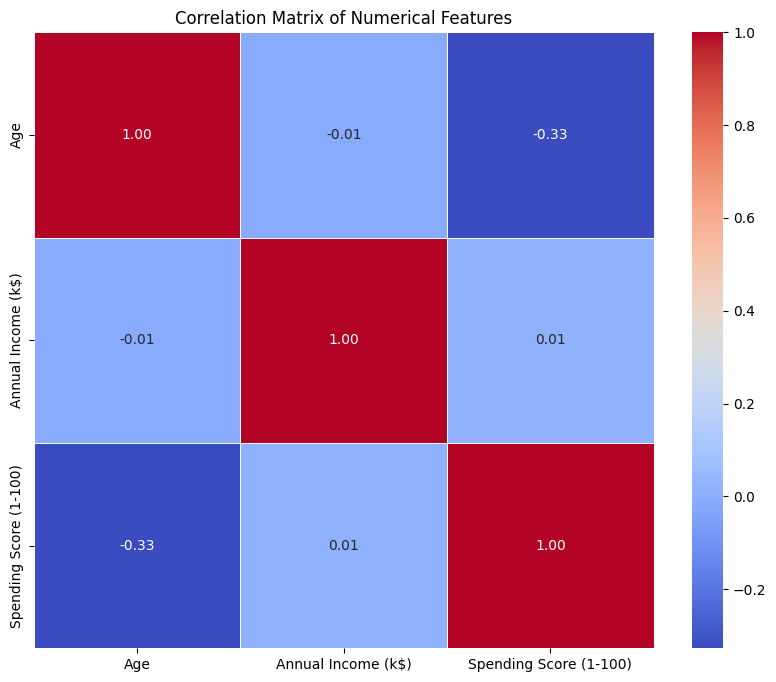

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## One-Hot

In [ ]:
# Apply one-hot encoding to the 'Genre' column and convert boolean to int
df = pd.get_dummies(df, columns=['Genre'], drop_first=True).astype(int)

display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## K-Means

### Annual Income, Spending Score

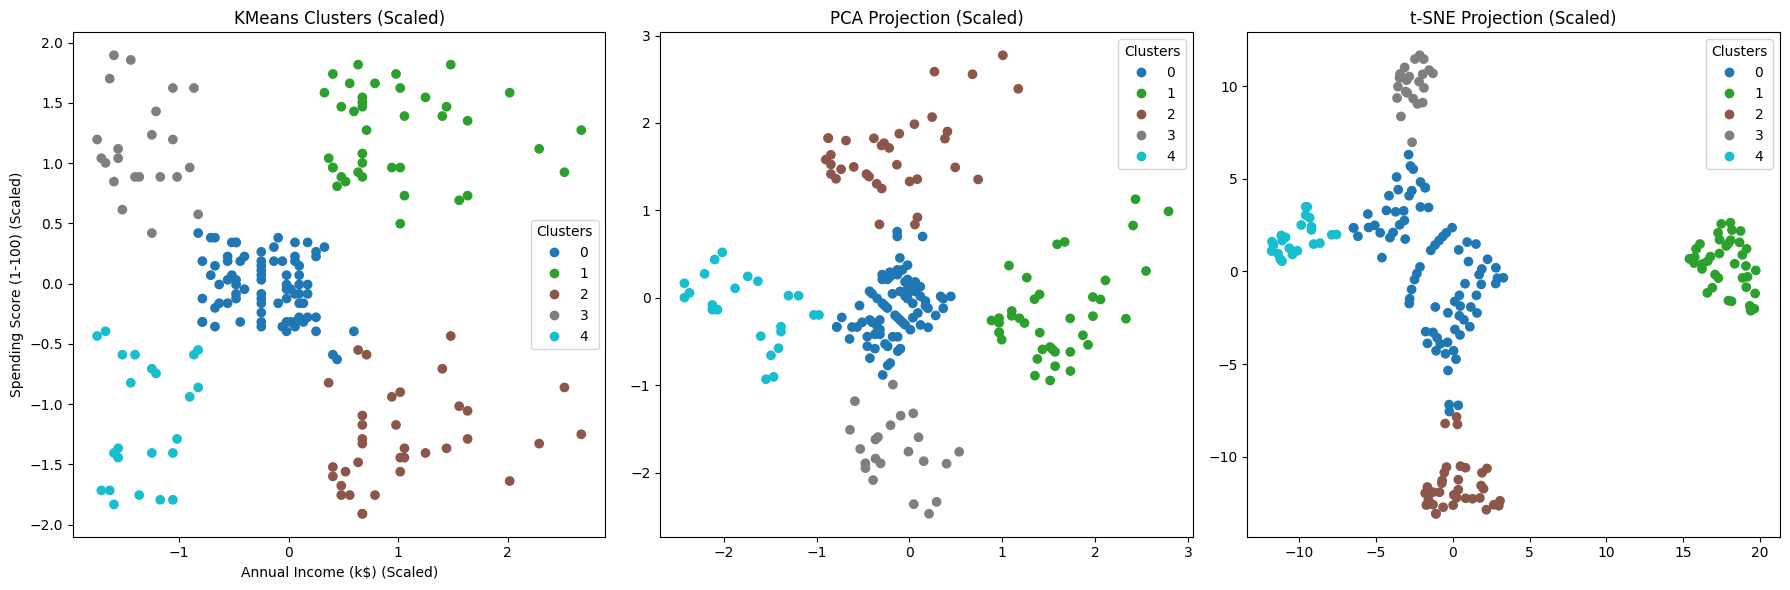

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use X_scaled for clustering and visualization
kmeans = KMeans(n_clusters=5, random_state=0)
labels = kmeans.fit_predict(X_scaled)

from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)

from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot KMeans
scatter_kmeans = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10')
axes[0].set_xlabel('Annual Income (k$) (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('KMeans Clusters (Scaled)')
axes[0].legend(*scatter_kmeans.legend_elements(), title="Clusters")

# Plot PCA
scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
axes[1].set_title('PCA Projection (Scaled)')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

# Plot t-SNE
scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10')
axes[2].set_title('t-SNE Projection (Scaled)')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

5 clusters:
- clients with low annual income and high spending score
- clients with medium annual income and medium spending score
- clients with high annual income and low spending score
- clients with high annual income and high spending score
- clients with low annual income and low spending score

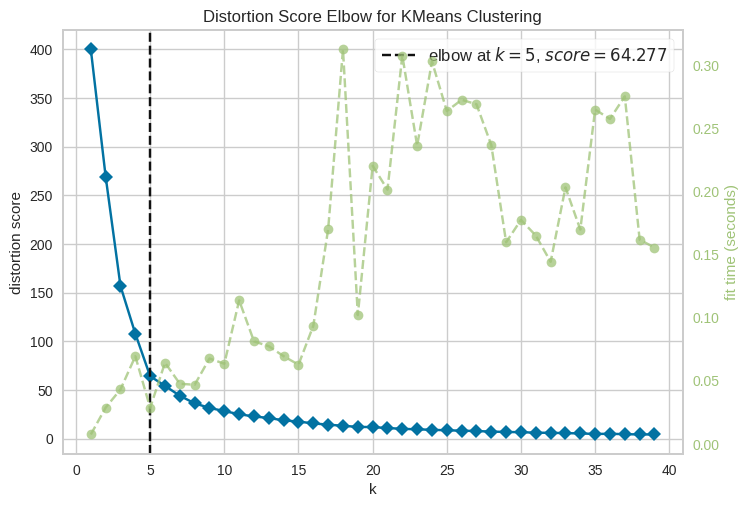

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt

# Select the features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use the KElbowVisualizer to find the optimal number of clusters
kmeans = KMeans(random_state=0, n_init=10) # Set n_init explicitly
visualizer = KElbowVisualizer(kmeans, k=(1,40)) # Test k from 1 to 10

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()               # Finalize and render the figure
plt.show()

### 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'

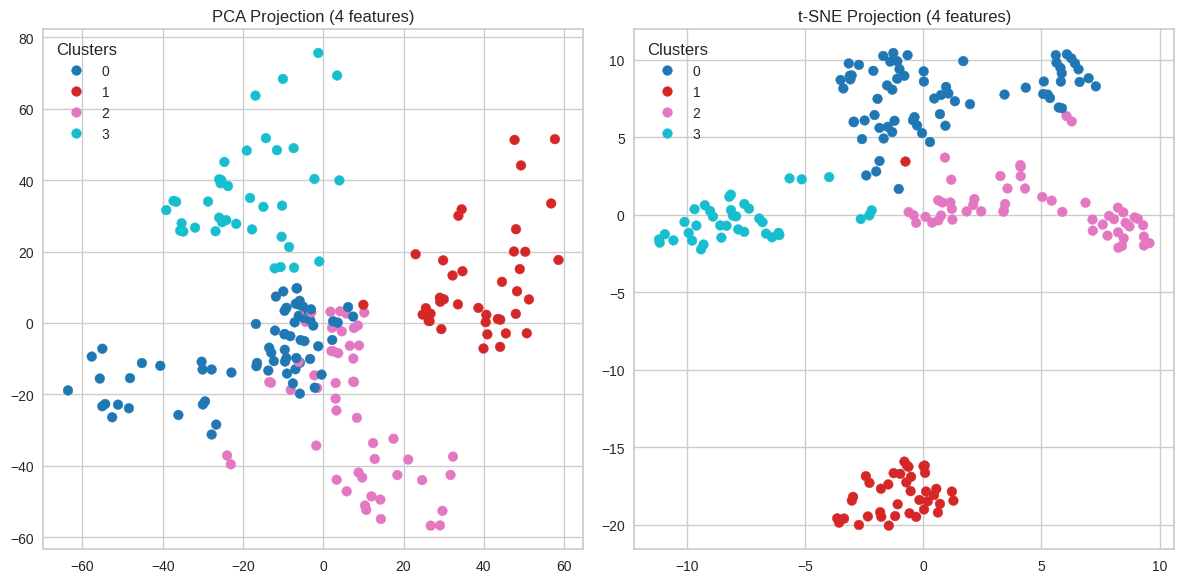

In [ ]:
# Use more features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(X)

# PCA visualization
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)

# t-SNE visualization
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X)

import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot PCA
scatter_pca = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
axes[0].set_title('PCA Projection (4 features)')
axes[0].legend(*scatter_pca.legend_elements(), title="Clusters")

# Plot t-SNE
scatter_tsne = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10')
axes[1].set_title('t-SNE Projection (4 features)')
axes[1].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

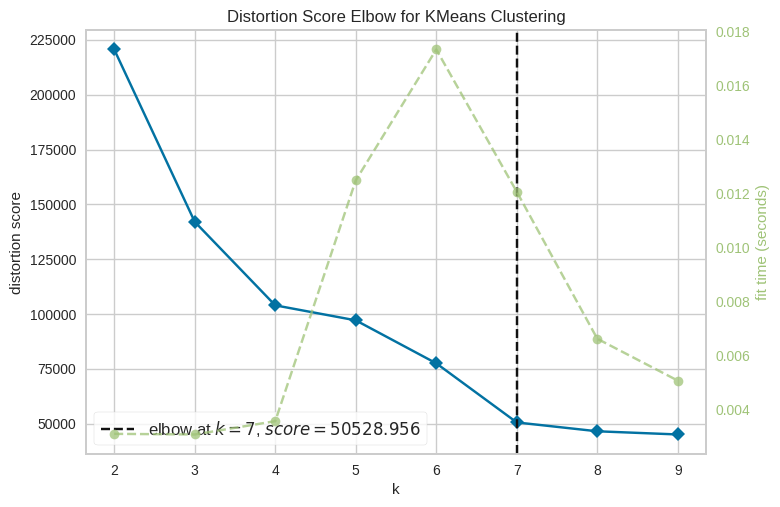

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

visualizer = KElbowVisualizer(kmeans, k=(2,10))
visualizer.fit(X)
visualizer.show()
plt.show()


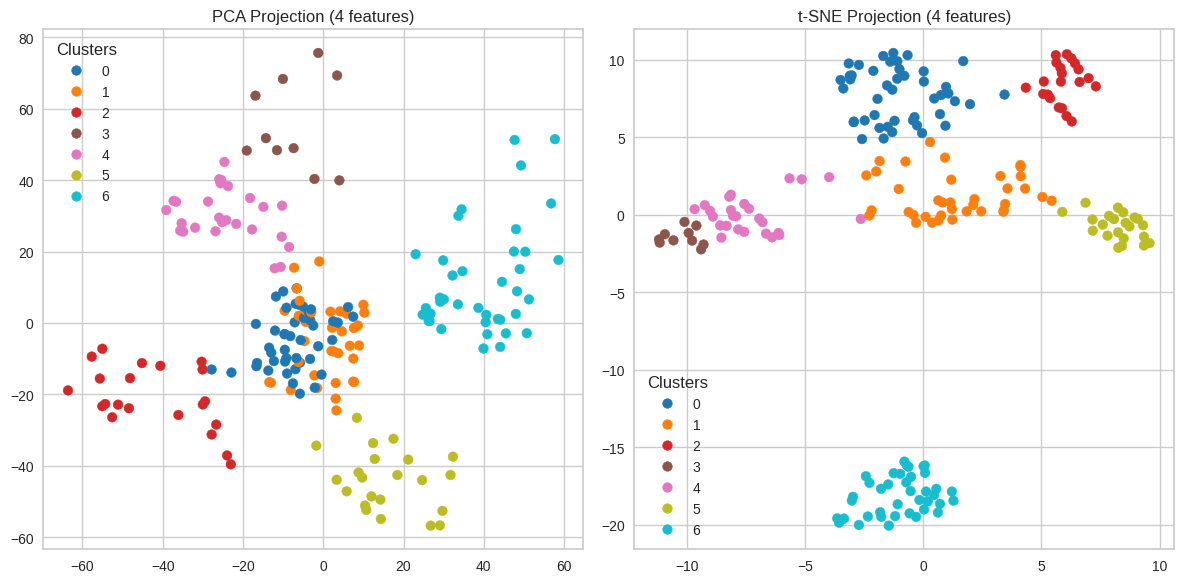

In [ ]:
# Use more features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# KMeans clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=7, random_state=0)
labels = kmeans.fit_predict(X)

# PCA visualization
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)

# t-SNE visualization
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X)

import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot PCA
scatter_pca = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
axes[0].set_title('PCA Projection (4 features)')
axes[0].legend(*scatter_pca.legend_elements(), title="Clusters")

# Plot t-SNE
scatter_tsne = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10')
axes[1].set_title('t-SNE Projection (4 features)')
axes[1].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

In [ ]:
df_clustered = df.copy()
df_clustered['Cluster'] = labels
df_clustered = df_clustered.drop('Genre_Male', axis=1)

summary = df_clustered.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary)

for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    print(f"\nDistribution of {col} by Cluster:")
    print(df_clustered.groupby('Cluster')[col].describe())

Age                Annual Income (k$)                  \
              mean median min max               mean median min  max   
Cluster                                                                
0        56.155556   54.0  43  70          53.377778   54.0  38   67   
1        27.108108   27.0  18  40          56.297297   59.0  39   76   
2        44.142857   45.0  19  67          25.142857   24.0  15   39   
3        41.000000   41.0  32  54         109.000000  103.0  97  130   
4        41.230769   43.0  19  59          79.269231   78.0  70   93   
5        25.272727   23.5  18  35          25.727273   24.5  15   39   
6        32.692308   32.0  27  40          86.358974   79.0  69  130   

        Spending Score (1-100)                 
                          mean median min max  
Cluster                                        
0                    49.088889   49.0  35  60  
1                    49.675676   50.0  34  61  
2                    19.523810   15.0   3  40  
3                    22.000000   20.5   8  39  
4                    15.923077   13.5   1  36  
5                    79.363636   77.0  61  99  
6                    82.128205   83.0  63  97


Distribution of Age by Cluster:
         count       mean        std   min    25%   50%    75%   max
Cluster                                                             
0         45.0  56.155556   8.543886  43.0  49.00  54.0  65.00  70.0
1         37.0  27.108108   7.097667  18.0  21.00  27.0  32.00  40.0
2         21.0  44.142857  13.089254  19.0  35.00  45.0  53.00  67.0
3         10.0  41.000000   7.118052  32.0  34.75  41.0  45.75  54.0
4         26.0  41.230769  12.522964  19.0  34.50  43.0  49.50  59.0
5         22.0  25.272727   5.257030  18.0  21.25  23.5  29.75  35.0
6         39.0  32.692308   3.728650  27.0  30.00  32.0  35.50  40.0

Distribution of Annual Income (k$) by Cluster:
         count        mean        std   min    25%    50%     75%    max
Cluster                                                                 
0         45.0   53.377778   8.435016  38.0  47.00   54.0   62.00   67.0
1         37.0   56.297297   9.786229  39.0  48.00   59.0   63.00   76.0
2     

1. **Cluster 0:**
    
    **Older, Average Income, Average Spenders**
    
    - Age: Oldest group (mean ≈ 56)
    - Income: Medium (mean ≈ $53k)
    - Spending: Average (mean ≈ 49)
2. **Cluster 1:**
    
    **Young Adults, Average Income, Average Spenders**
    
    - Age: Young (mean ≈ 27)
    - Income: Medium (mean ≈ $56k)
    - Spending: Average (mean ≈ 50)
3. **Cluster 2:**
    
    **Middle-Aged, Low Income, Low Spenders**
    
    - Age: Middle-aged (mean ≈ 44)
    - Income: Low (mean ≈ $25k)
    - Spending: Low (mean ≈ 20)
4. **Cluster 3:**
    
    **Middle-Aged, Very High Income, Low Spenders**
    
    - Age: Middle-aged (mean ≈ 41)
    - Income: Very high (mean ≈ $109k)
    - Spending: Low (mean ≈ 22)
5. **Cluster 4:**
    
    **Middle-Aged, High Income, Very Low Spenders**
    
    - Age: Middle-aged (mean ≈ 41)
    - Income: High (mean ≈ $79k)
    - Spending: Very low (mean ≈ 16)
6. **Cluster 5:**
    
    **Young, Low Income, High Spenders**
    
    - Age: Youngest (mean ≈ 25)
    - Income: Low (mean ≈ $26k)
    - Spending: High (mean ≈ 79)
7. **Cluster 6:**
    
    **Young Adults, High Income, Very High Spenders**
    
    - Age: Young adults (mean ≈ 33)
    - Income: High (mean ≈ $86k)
    - Spending: Very high (mean ≈ 82)

### Spending, Age

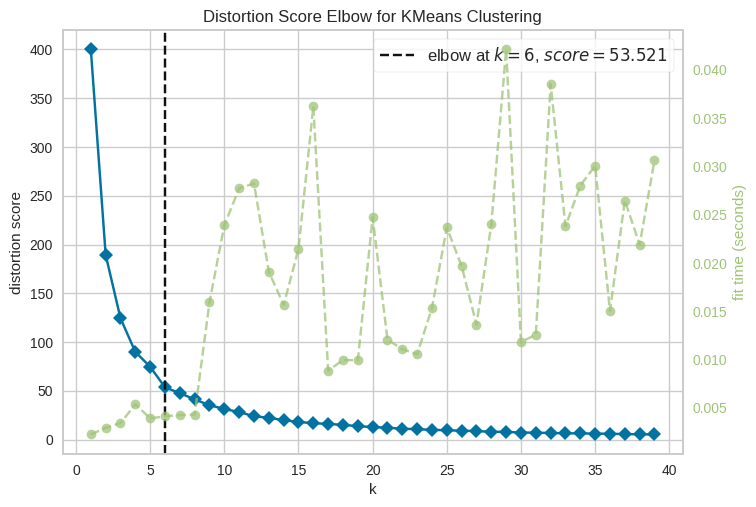

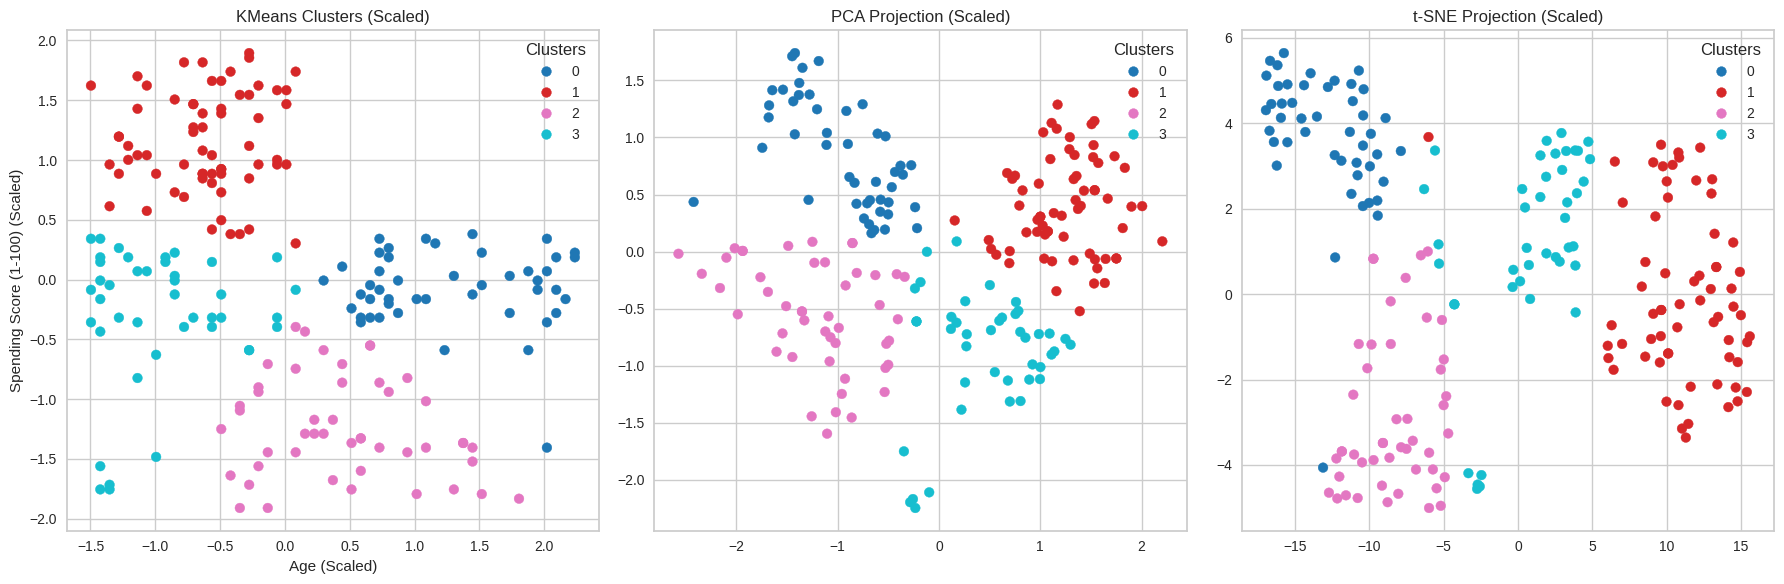

In [ ]:
X = df[['Age', 'Spending Score (1-100)']].values

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use X_scaled for clustering and visualization
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(X_scaled)

visualizer = KElbowVisualizer(kmeans, k=(1,40))
visualizer.fit(X_scaled)
visualizer.show()
plt.show()

from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X_scaled)

from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

import matplotlib.pyplot as plt
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot KMeans
scatter_kmeans = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('KMeans Clusters (Scaled)')
axes[0].legend(*scatter_kmeans.legend_elements(), title="Clusters")

# Plot PCA
scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10')
axes[1].set_title('PCA Projection (Scaled)')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

# Plot t-SNE
scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10')
axes[2].set_title('t-SNE Projection (Scaled)')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

In [ ]:
df_clustered = df.copy()
df_clustered['Cluster'] = labels
df_clustered = df_clustered.drop('Genre_Male', axis=1)
df_clustered = df_clustered.drop('Annual Income (k$)', axis=1)

summary = df_clustered.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary)

Age                Spending Score (1-100)               
              mean median min max                   mean median min max
Cluster                                                                
0        56.565217   54.5  43  70              48.304348   48.5  14  60
1        30.292308   31.0  18  40              79.815385   78.0  58  99
2        45.276596   45.0  32  64              18.191489   16.0   1  40
3        25.500000   24.5  18  40              42.261905   46.5   5  59

- **Cluster 0 (blue):** Older, Moderate Spending    
- **Cluster 1 (pink):** Younger, Low Spending        
- **Cluster 2 (red):** Younger, High Spending        
- **Cluster 3 (cyan):** Older, Moderate Spending

In [ ]:
# Assuming you have your original DataFrame as df and cluster labels as 'labels'

# Add cluster labels to the DataFrame
df_clustered = df.copy()
df_clustered['Cluster'] = labels
df_clustered = df_clustered.drop('Genre_Male', axis=1)
df_clustered = df_clustered.drop('Annual Income (k$)', axis=1)

# Get mean, median, min, max for each feature by cluster
summary = df_clustered.groupby('Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary)

# Get distribution (value counts or histograms) for each feature by cluster
for col in ['Age', 'Spending Score (1-100)']:
    print(f"\nDistribution of {col} by Cluster:")
    print(df_clustered.groupby('Cluster')[col].describe())

Age                Spending Score (1-100)               
              mean median min max                   mean median min max
Cluster                                                                
0        56.565217   54.5  43  70              48.304348   48.5  14  60
1        30.292308   31.0  18  40              79.815385   78.0  58  99
2        45.276596   45.0  32  64              18.191489   16.0   1  40
3        25.500000   24.5  18  40              42.261905   46.5   5  59


Distribution of Age by Cluster:
         count       mean       std   min    25%   50%    75%   max
Cluster                                                            
0         46.0  56.565217  8.505298  43.0  49.00  54.5  65.75  70.0
1         65.0  30.292308  5.594984  18.0  27.00  31.0  35.00  40.0
2         47.0  45.276596  8.360628  32.0  38.50  45.0  51.00  64.0
3         42.0  25.500000  6.504220  18.0  19.25  24.5  30.50  40.0

Distribution of Spending Score (1-100) by Cluster:
         count       mean        std   min    25%   50%   75%   max
Cluster                                                            
0         46.0  48.304348   8.096281  14.0  44.25  48.5  54.5  60.0
1         65.0  79.815385  10.809273  58.0  73.00  78.0  89.0  99.0
2         47.0  18.191489  10.723072   1.0  10.50  16.0  26.5  40.0
3         42.0  42.261905  14.825916   5.0  40.00  46.5  53.5  59.0


## Gaussian Mixture Model (GMM) Clustering


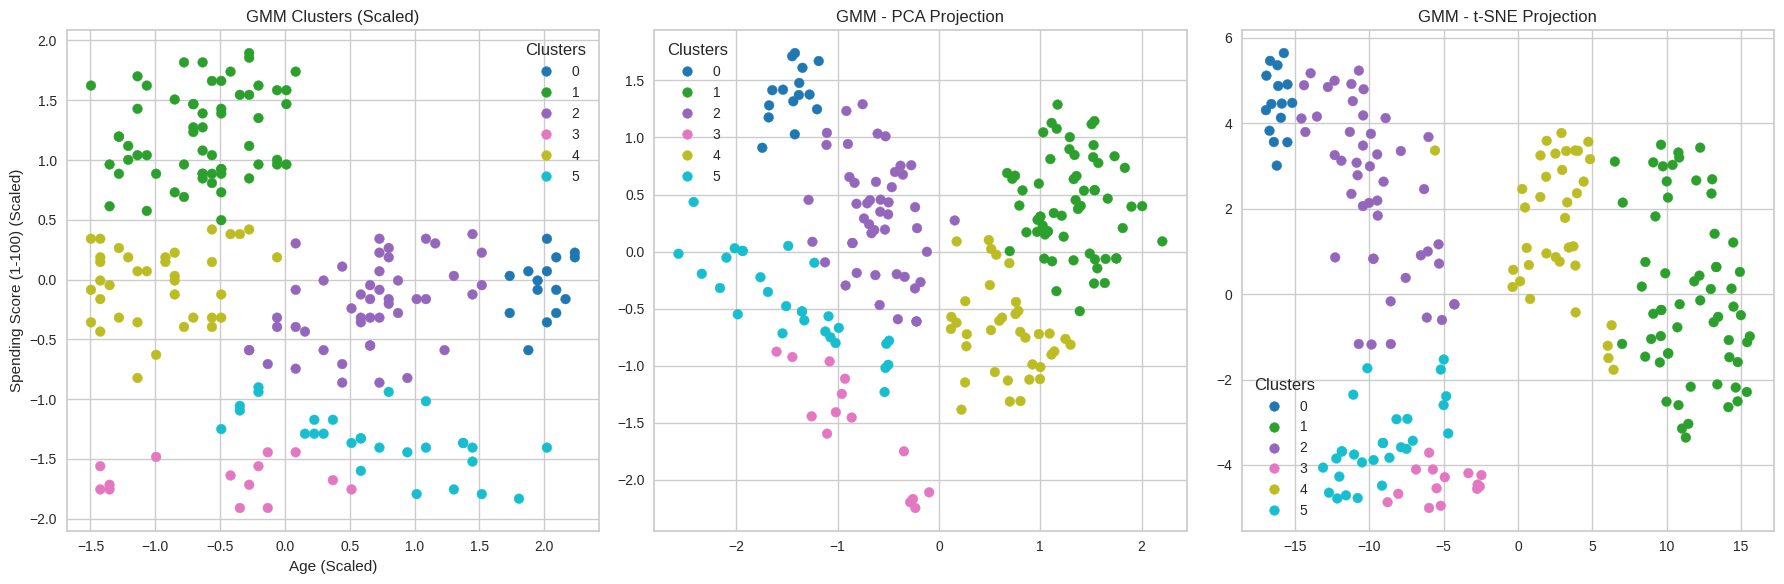

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for GMM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit GMM (number of components as in K-Means)
gmm = GaussianMixture(n_components=6, covariance_type='full', random_state=0)
gmm_labels = gmm.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot GMM on scaled data
scatter_gmm = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('GMM Clusters (Scaled)')
axes[0].legend(*scatter_gmm.legend_elements(), title="Clusters")

scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10')
axes[1].set_title('GMM - PCA Projection')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=gmm_labels, cmap='tab10')
axes[2].set_title('GMM - t-SNE Projection')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")


plt.tight_layout()
plt.show()

### GMM Cluster Analysis


In [ ]:
df_gmm = df.copy()
df_gmm['GMM_Cluster'] = gmm_labels
df_gmm = df_gmm.drop('Genre_Male', axis=1)
df_gmm = df_gmm.drop('Annual Income (k$)', axis=1)

summary_gmm = df_gmm.groupby('GMM_Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary_gmm)


Age                Spending Score (1-100)               
                  mean median min max                   mean median min max
GMM_Cluster                                                                
0            66.800000   67.0  63  70              48.933333   50.0  35  59
1            29.933333   30.0  18  40              81.466667   80.0  63  99
2            47.808511   48.0  35  60              44.638298   46.0  28  60
3            31.785714   34.5  19  46               7.285714    6.5   1  13
4            25.416667   25.5  18  38              49.416667   50.5  29  61
5            48.750000   48.0  32  67              15.678571   15.5   3  27

0. older, moderate
1. young adults, high spending
2. adults, moderate spending,
4. young, moderate spending

## DBSCAN Clustering

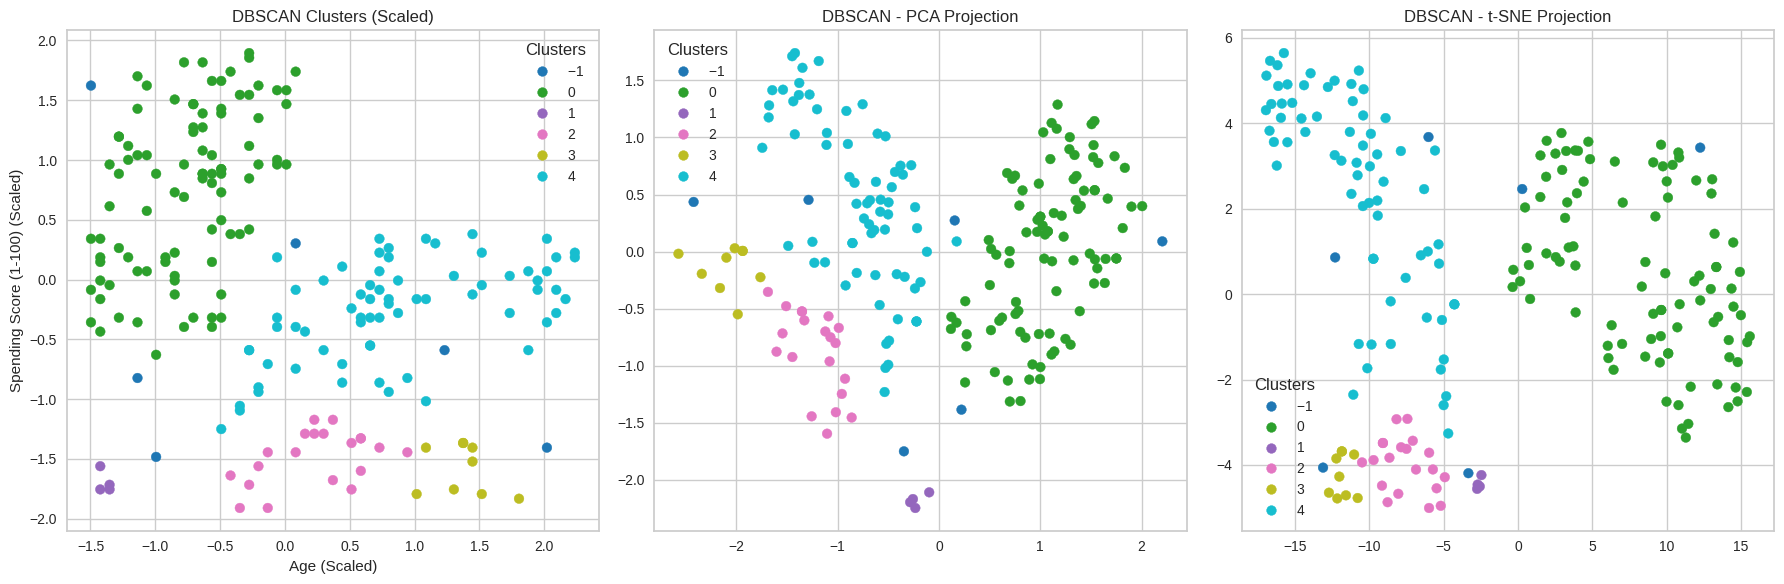

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Use the same features as in K-Means
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for DBSCAN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit DBSCAN
clustering = DBSCAN(eps=0.31, min_samples=4)
db_labels = clustering.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# Plot PCA and t-SNE results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot DBSCAN on scaled data
scatter_dbscan = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=db_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('DBSCAN Clusters (Scaled)')
axes[0].legend(*scatter_dbscan.legend_elements(), title="Clusters")


scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10')
axes[1].set_title('DBSCAN - PCA Projection')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_labels, cmap='tab10')
axes[2].set_title('DBSCAN - t-SNE Projection')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

### DBSCAN Cluster Analysis


In [ ]:
df_dbscan = df.copy()
df_dbscan['DBSCAN_Cluster'] = db_labels
df_dbscan = df_dbscan.drop('Genre_Male', axis=1)
df_dbscan = df_dbscan.drop('Annual Income (k$)', axis=1)

summary_dbscan = df_dbscan.groupby('DBSCAN_Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary_dbscan)



Age                Spending Score (1-100)               
                     mean median min max                   mean median min max
DBSCAN_Cluster                                                                
-1              38.166667   32.5  18  67              40.000000   32.0  12  92
 0              28.301075   29.0  18  40              69.795699   73.0  34  99
 1              19.500000   19.5  19  20               6.500000    5.5   5  10
 2              42.100000   42.5  33  52              11.900000   13.0   1  20
 3              58.000000   58.0  53  64               9.444444   11.0   3  15
 4              50.985294   49.0  32  70              43.529412   46.0  18  60

### OPTICS and silhouette_score metrics

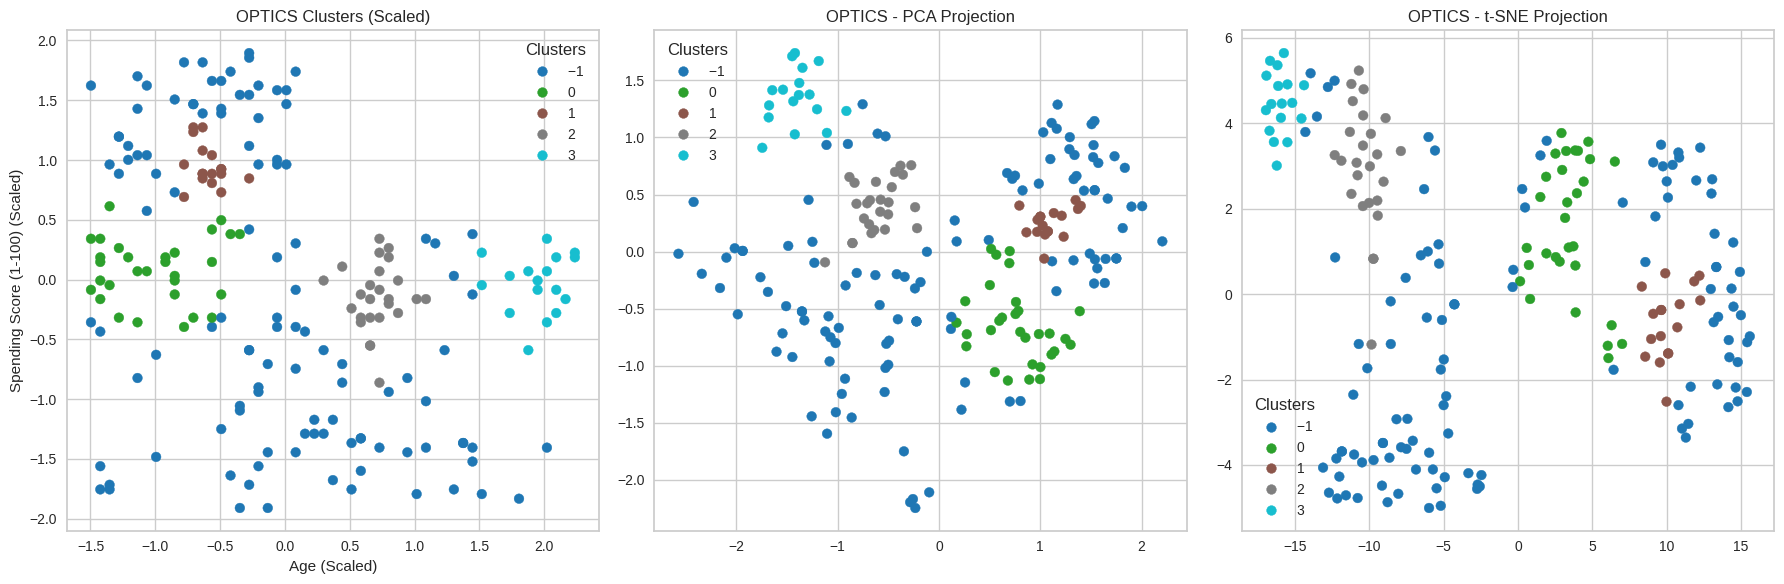

Silhouette Score for OPTICS: 0.5920419448962918


In [ ]:
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for OPTICS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit OPTICS
optics = OPTICS(min_samples=10) # You may need to adjust min_samples
optics_labels = optics.fit_predict(X_scaled)

# Plotting (similar to DBSCAN)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot OPTICS on scaled data
scatter_optics = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=optics_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('OPTICS Clusters (Scaled)')
axes[0].legend(*scatter_optics.legend_elements(), title="Clusters")


# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=optics_labels, cmap='tab10')
axes[1].set_title('OPTICS - PCA Projection')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")


# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)
scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=optics_labels, cmap='tab10')
axes[2].set_title('OPTICS - t-SNE Projection')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")


plt.tight_layout()
plt.show()

# Evaluate OPTICS using silhouette score
# Exclude noise points (label -1) for silhouette score calculation
if len(np.unique(optics_labels)) > 1:
    silhouette_avg = silhouette_score(X_scaled[optics_labels != -1], optics_labels[optics_labels != -1])
    print(f"Silhouette Score for OPTICS: {silhouette_avg}")
else:
    print("OPTICS found only one cluster or only noise points. Cannot calculate silhouette score.")

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Calculate silhouette score for the DBSCAN results
# Exclude noise points (label -1) for silhouette score calculation
if len(np.unique(db_labels)) > 1:
    silhouette_avg_dbscan = silhouette_score(X_scaled[db_labels != -1], db_labels[db_labels != -1])
    print(f"Silhouette Score for DBSCAN: {silhouette_avg_dbscan}")
else:
    print("DBSCAN found only one cluster or only noise points. Cannot calculate silhouette score.")

Silhouette Score for DBSCAN: 0.38743809851412553


### DBSCAN GS

In [ ]:
# from sklearn.cluster import DBSCAN
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # === 1. Prepare data ===
# X = df[['Age', 'Spending Score (1-100)']].values
# X_scaled = StandardScaler().fit_transform(X)

# # === 2. Define parameter grid ===
# eps_values = np.arange(0.30, 0.31, 0.307, 0.312)
# min_samples_values = [3, 4, 5, 6, 8, 10]
# metrics = ['euclidean', 'manhattan', 'cosine']

# results = []

# # === 3. Grid search ===
# for eps in eps_values:
#     for ms in min_samples_values:
#         for metric in metrics:
#             model = DBSCAN(eps=eps, min_samples=ms, metric=metric)
#             labels = model.fit_predict(X_scaled)
#             mask = labels != -1  # exclude noise points

#             n_clusters = len(set(labels[mask]))
#             if n_clusters > 1:  # need at least 2 clusters for valid scores
#                 sil = silhouette_score(X_scaled[mask], labels[mask])
#                 db = davies_bouldin_score(X_scaled[mask], labels[mask])
#                 ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
#                 results.append((eps, ms, metric, sil, db, ch, n_clusters))
#             else:
#                 results.append((eps, ms, metric, np.nan, np.nan, np.nan, n_clusters))

# # === 4. Store results ===
# results_df = pd.DataFrame(results, columns=[
#     'eps', 'min_samples', 'metric', 'Silhouette', 'DaviesBouldin', 'CalinskiHarabasz', 'Clusters'
# ])

# # === 5. Find best parameters (by Silhouette) ===
# best = results_df.sort_values(by='Silhouette', ascending=False).head(1)
# print("Best DBSCAN parameters based on Silhouette Score:")
# print(best)

# # === 6. Fit DBSCAN with best parameters ===
# best_params = best.iloc[0]
# best_model = DBSCAN(
#     eps=best_params['eps'],
#     min_samples=int(best_params['min_samples']),
#     metric=best_params['metric']
# ).fit(X_scaled)
# labels_best = best_model.labels_

# # === 7. Visualization ===
# X_pca = PCA(n_components=2).fit_transform(X_scaled)
# X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# # Scaled space
# axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_best, cmap='tab10')
# axes[0].set_title(f"DBSCAN (Scaled)\neps={best_params['eps']:.2f}, min_samples={int(best_params['min_samples'])}, metric={best_params['metric']}")

# # PCA
# axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_best, cmap='tab10')
# axes[1].set_title("DBSCAN - PCA Projection")

# # t-SNE
# axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_best, cmap='tab10')
# axes[2].set_title("DBSCAN - t-SNE Projection")

# plt.tight_layout()
# plt.show()

# # === 8. Print metrics ===
# print(f"\n✅ Best parameters:")
# print(f"eps = {best_params['eps']:.2f}")
# print(f"min_samples = {int(best_params['min_samples'])}")
# print(f"metric = '{best_params['metric']}'")
# print(f"Clusters found: {int(best_params['Clusters'])}")
# print(f"Silhouette Score = {best_params['Silhouette']:.4f}")
# print(f"Davies–Bouldin Index = {best_params['DaviesBouldin']:.4f}")
# print(f"Calinski–Harabasz Score = {best_params['CalinskiHarabasz']:.4f}")

TypeError: Cannot interpret '0.312' as a data type

## Mean Shift Clustering

0.7819554319207919


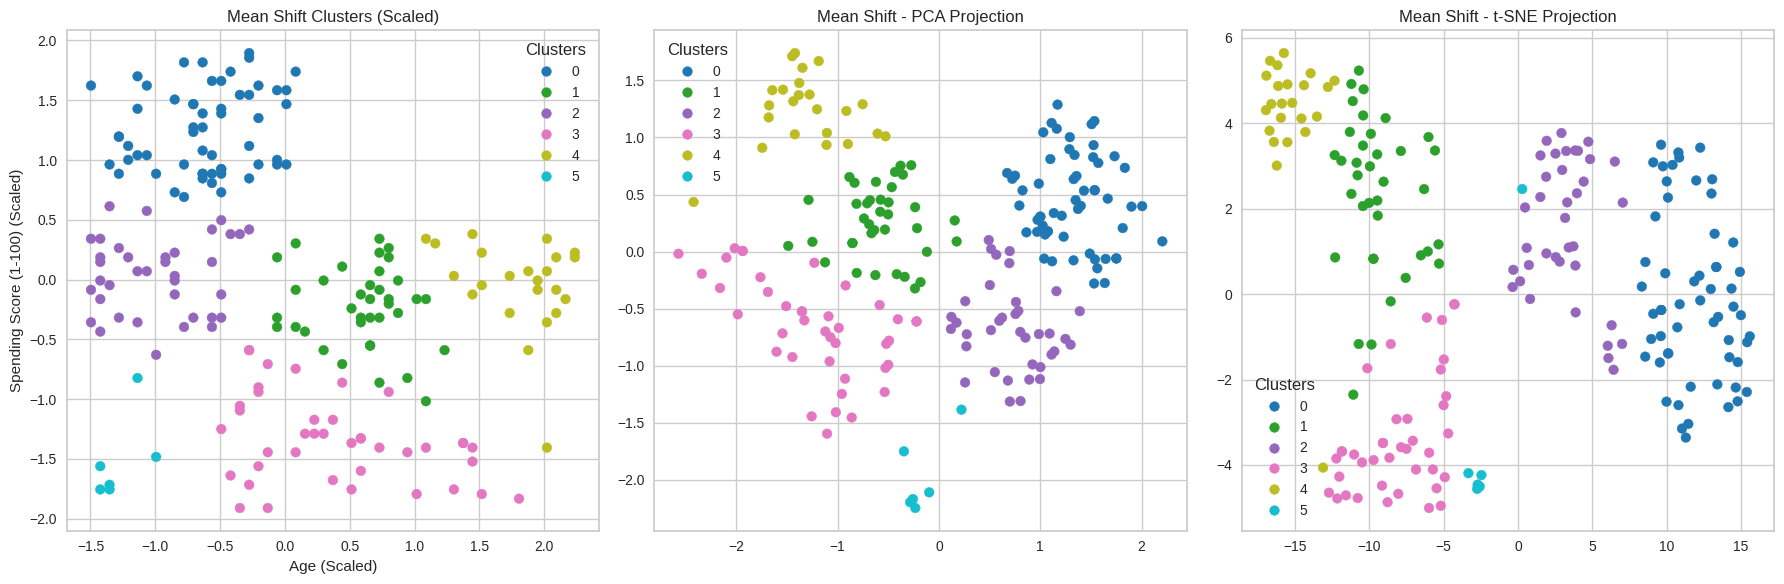

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for Mean Shift
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Estimate bandwidth for Mean Shift
bandwidth = estimate_bandwidth(X_scaled, quantile=0.14)
print(bandwidth)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, min_bin_freq=1)
ms_labels = ms.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# Plot PCA and t-SNE results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Mean Shift on scaled data
scatter_ms = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=ms_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('Mean Shift Clusters (Scaled)')
axes[0].legend(*scatter_ms.legend_elements(), title="Clusters")

scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=ms_labels, cmap='tab10')
axes[1].set_title('Mean Shift - PCA Projection')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=ms_labels, cmap='tab10')
axes[2].set_title('Mean Shift - t-SNE Projection')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

### Mean Shift Cluster Analysis

In [ ]:
df_ms = df.copy()
df_ms['MS_Cluster'] = ms_labels
df_ms = df_ms.drop('Annual Income (k$)', axis=1)
df_ms = df_ms.drop('Genre_Male', axis=1)

summary_ms = df_ms.groupby('MS_Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary_ms)

Age                Spending Score (1-100)               
                 mean median min max                   mean median min max
MS_Cluster                                                                
0           28.113636   29.0  18  40              72.079545   74.0  39  99
1           47.285714   48.0  19  70              33.008929   36.0   1  60

### Kernel

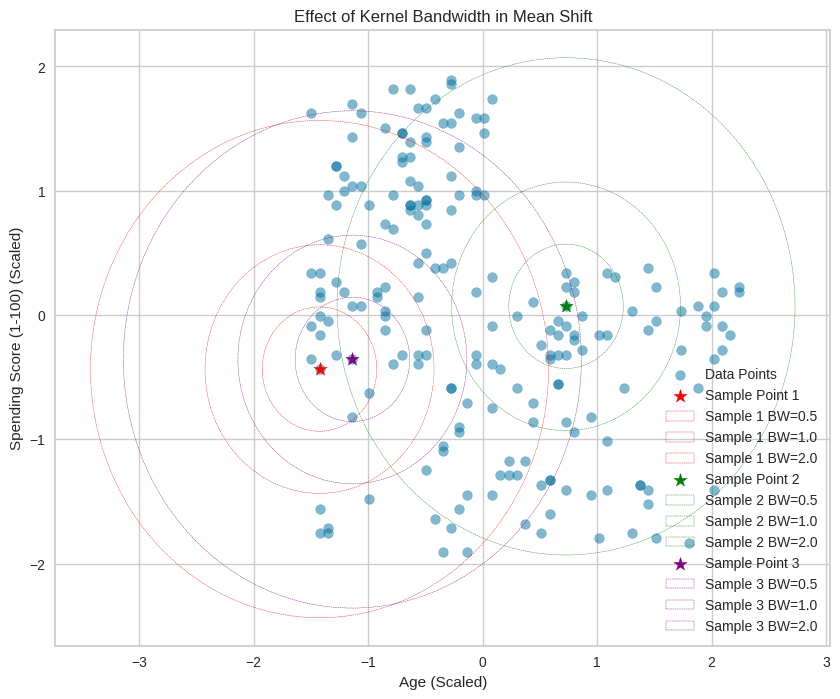

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for Mean Shift
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Select a few data points to illustrate the kernel effect
sample_indices = [0, 50, 100]
sample_points = X_scaled[sample_indices]

# Define different bandwidths to visualize
bandwidths = [0.5, 1.0, 2.0] # You can adjust these values

plt.figure(figsize=(10, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.5, label='Data Points')

colors = ['red', 'green', 'purple']

for i, point in enumerate(sample_points):
    plt.scatter(point[0], point[1], color=colors[i], s=100, marker='*', label=f'Sample Point {i+1}')
    for bw in bandwidths:
        # Draw circles representing the kernel with different bandwidths
        circle = plt.Circle((point[0], point[1]), bw, color=colors[i], fill=False, linestyle='--', label=f'Sample {i+1} BW={bw}')
        plt.gca().add_patch(circle)

plt.title('Effect of Kernel Bandwidth in Mean Shift')
plt.xlabel('Age (Scaled)')
plt.ylabel('Spending Score (1-100) (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

0.7819554319207919


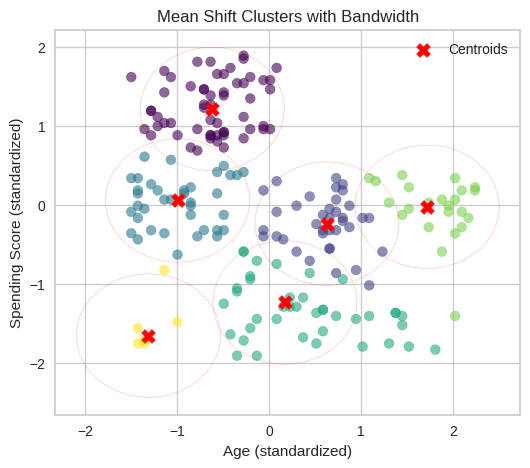

In [ ]:
X = df[['Age', 'Spending Score (1-100)']].values

# Standardizare
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Estimate bandwidth
bandwidth = estimate_bandwidth(X_scaled, quantile=0.14)
print(bandwidth)

# Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_scaled)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

# Plot clusters with bandwidth circles
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis', s=50, alpha=0.6)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='red', s=100, marker='X', label='Centroids')

# Draw bandwidth circles
for center in cluster_centers:
    circle = plt.Circle(center, bandwidth, color='red', fill=False, linestyle='--', alpha=0.5)
    plt.gca().add_patch(circle)

plt.title('Mean Shift Clusters with Bandwidth')
plt.xlabel('Age (standardized)')
plt.ylabel('Spending Score (standardized)')
plt.legend()
plt.show()

## Grid Seach for Mean Shift

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Definire grid parametri
quantiles = [0.1, 0.14, 0.2, 0.25, 0.3]
bin_seeding_options = [True, False]
min_bin_freq_options = [1, 3, 5]

best_score = -1
best_params = {}
results = []

# Grid Search manual (Mean Shift nu suportă GridSearchCV direct)
for quantile in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=quantile)

    for bin_seed in bin_seeding_options:
        for min_freq in min_bin_freq_options:
            try:
                ms = MeanShift(
                    bandwidth=bandwidth,
                    bin_seeding=bin_seed,
                    min_bin_freq=min_freq
                )
                labels = ms.fit_predict(X_scaled)

                # Evaluare (min 2 clustere pentru silhouette)
                if len(np.unique(labels)) > 1:
                    sil_score = silhouette_score(X_scaled, labels)
                    db_score = davies_bouldin_score(X_scaled, labels)

                    results.append({
                        'quantile': quantile,
                        'bandwidth': bandwidth,
                        'bin_seeding': bin_seed,
                        'min_bin_freq': min_freq,
                        'n_clusters': len(np.unique(labels)),
                        'silhouette': sil_score,
                        'davies_bouldin': db_score
                    })

                    if sil_score > best_score:
                        best_score = sil_score
                        best_params = {
                            'quantile': quantile,
                            'bandwidth': bandwidth,
                            'bin_seeding': bin_seed,
                            'min_bin_freq': min_freq
                        }
            except:
                continue

# Rezultate
import pandas as pd
results_df = pd.DataFrame(results)
print("Best parameters:", best_params)
print("\nTop 5 configurations:")
print(results_df.sort_values('silhouette', ascending=False).head())

Best parameters: {'quantile': 0.3, 'bandwidth': np.float64(1.2419016453933969), 'bin_seeding': True, 'min_bin_freq': 1}

Top 5 configurations:
    quantile  bandwidth  bin_seeding  min_bin_freq  n_clusters  silhouette  \
26      0.30   1.241902         True             5           2    0.460726   
24      0.30   1.241902         True             1           2    0.460726   
25      0.30   1.241902         True             3           2    0.460726   
23      0.25   1.097096        False             5           2    0.459626   
13      0.20   0.957802         True             3           2    0.459626   

    davies_bouldin  
26        0.835059  
24        0.835059  
25        0.835059  
23        0.833590  
13        0.833590  


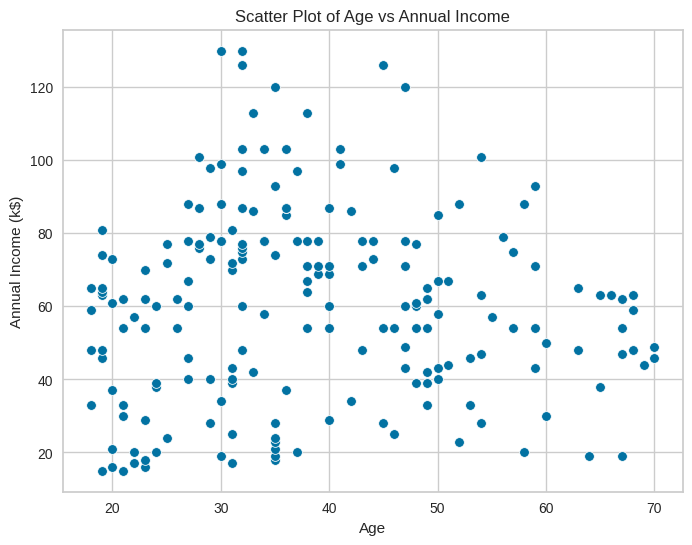

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)')
plt.title('Scatter Plot of Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

## Agglomerative Clustering


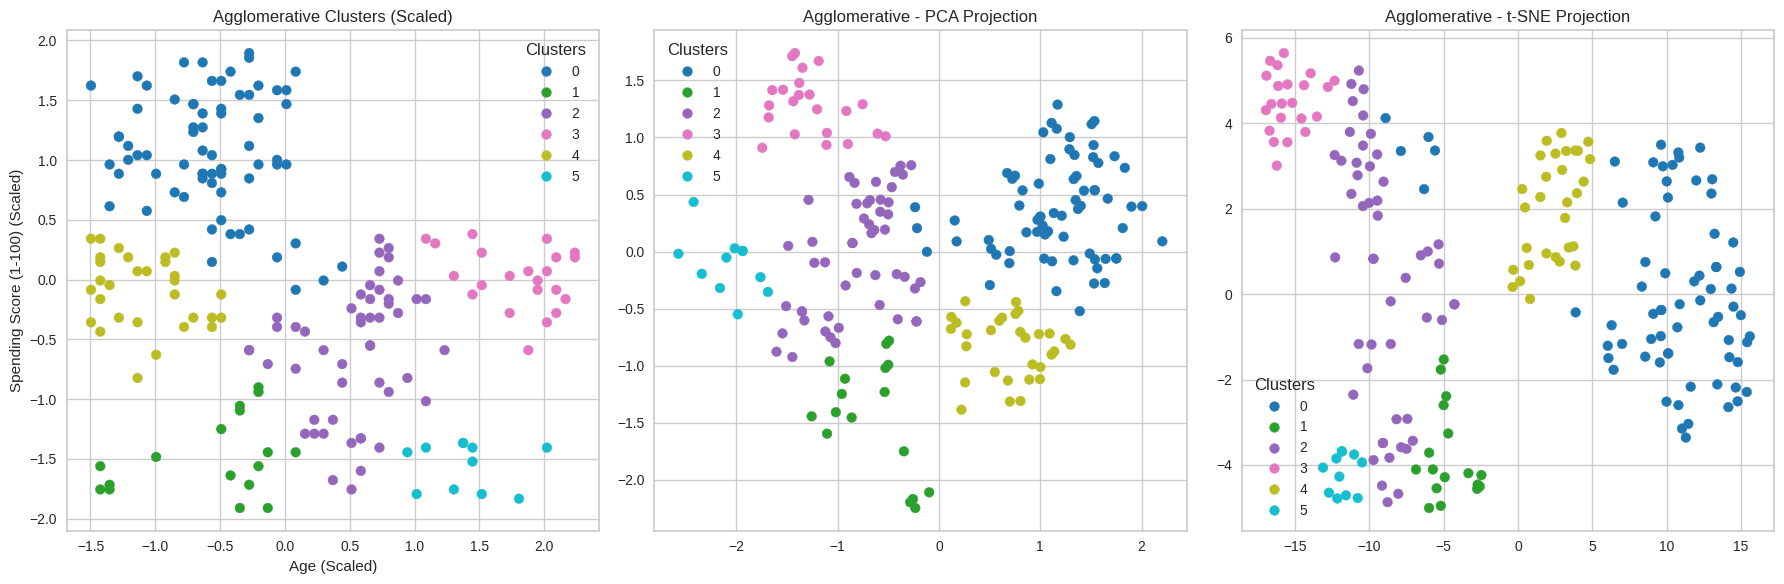

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for Agglomerative Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Agglomerative Clustering (number of clusters can be set as in K-Means)
agglo = AgglomerativeClustering(n_clusters=6)
agglo_labels = agglo.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# Plot PCA and t-SNE results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Agglomerative Clustering on scaled data
scatter_agglo = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=agglo_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('Agglomerative Clusters (Scaled)')
axes[0].legend(*scatter_agglo.legend_elements(), title="Clusters")

scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='tab10')
axes[1].set_title('Agglomerative - PCA Projection')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=agglo_labels, cmap='tab10')
axes[2].set_title('Agglomerative - t-SNE Projection')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()

### Agglomerative Cluster Analysis


In [ ]:
df_agglo = df.copy()
df_agglo['Agglo_Cluster'] = agglo_labels
df_agglo = df_agglo.drop('Genre_Male', axis=1)
df_agglo = df_agglo.drop('Annual Income (k$)', axis=1)

summary_agglo = df_agglo.groupby('Agglo_Cluster').agg(['mean', 'median', 'min', 'max'])
display(summary_agglo)


Age                Spending Score (1-100)               
                    mean median min max                   mean median min max
Agglo_Cluster                                                                
0              30.942857   31.0  18  45              77.828571   77.0  48  99
1              31.000000   34.0  19  40              12.117647   10.0   1  27
2              46.340000   47.0  35  56              34.640000   36.0   5  59
3              63.909091   65.5  54  70              50.636364   51.0  35  60
4              23.766667   23.0  18  32              47.600000   48.5  29  59
5              58.272727   58.0  52  67              10.181818   13.0   3  15

### Agl clustering - trashhold

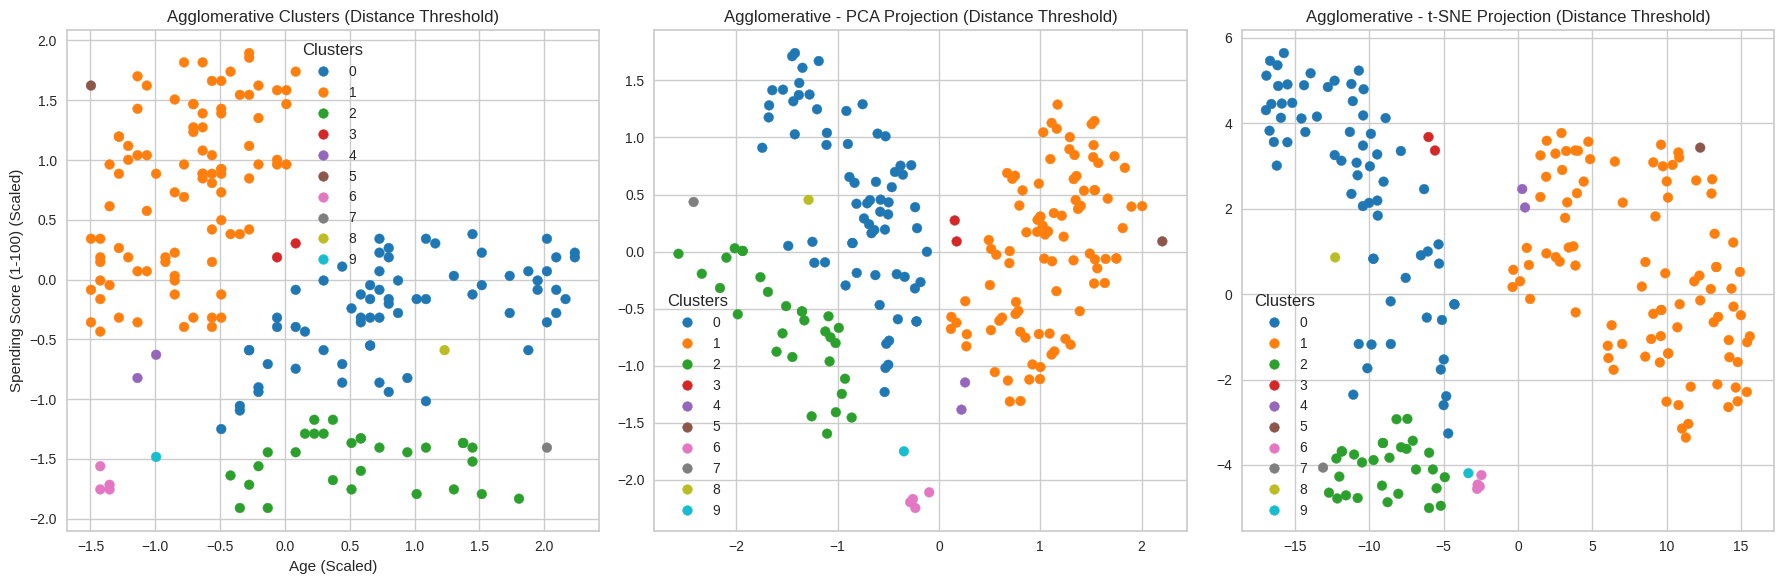

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use the same features as before
X = df[['Age', 'Spending Score (1-100)']].values

# Standardize features for Agglomerative Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Agglomerative Clustering using a distance threshold
# You can adjust the distance_threshold as needed
agglo = AgglomerativeClustering(n_clusters=None,
                                distance_threshold=0.299,
                                linkage='single'  # sau ward, 'single', 'complete', 'average'
                                )

agglo_labels = agglo.fit_predict(X_scaled)

# PCA projection
X_pca = PCA(n_components=2).fit_transform(X_scaled)
# t-SNE projection
X_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_scaled)

# Plot PCA and t-SNE results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Agglomerative Clustering on scaled data
scatter_agglo = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=agglo_labels, cmap='tab10')
axes[0].set_xlabel('Age (Scaled)')
axes[0].set_ylabel('Spending Score (1-100) (Scaled)')
axes[0].set_title('Agglomerative Clusters (Distance Threshold)')
axes[0].legend(*scatter_agglo.legend_elements(), title="Clusters")

scatter_pca = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='tab10')
axes[1].set_title('Agglomerative - PCA Projection (Distance Threshold)')
axes[1].legend(*scatter_pca.legend_elements(), title="Clusters")

scatter_tsne = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=agglo_labels, cmap='tab10')
axes[2].set_title('Agglomerative - t-SNE Projection (Distance Threshold)')
axes[2].legend(*scatter_tsne.legend_elements(), title="Clusters")

plt.tight_layout()
plt.show()